**SF1930 Report**


Jonathan Tadesse

In [16]:
#Import modules neccessary
import pandas as pd
import numpy as np
import scipy
from matplotlib import pyplot as plt

#Read
df = pd.read_csv("SLS22.csv")
print(df.to_string())

           id      location  month  year        comp  heat  run 1  run 2  trick 1  trick 2  trick 3  trick 4  trick 5  trick 6
0      Berger  jacksonville      7  2022  prelim men     1    5.0    1.1      7.0      0.0      7.6      0.0      NaN      NaN
1        Papa  jacksonville      7  2022  prelim men     1    3.7    7.0      7.2      0.0      8.4      8.2      NaN      NaN
2     Pudwill  jacksonville      7  2022  prelim men     1    2.0    1.3      0.0      0.0      0.0      0.0      NaN      NaN
3      Shirai  jacksonville      7  2022  prelim men     1    7.9    7.0      7.5      0.0      9.2      0.0      NaN      NaN
4        Mota  jacksonville      7  2022  prelim men     1    3.8    4.0      7.8      0.0      0.0      0.0      NaN      NaN
5   Ribeiro G  jacksonville      7  2022  prelim men     2    8.1    5.7      0.0      8.8      8.1      0.0      NaN      NaN
6     Decenzo  jacksonville      7  2022  prelim men     2    4.6    5.0      7.8      0.0      0.0      0.0   

lets view the data

In [17]:
df

,id,location,month,year,comp,heat,run 1,run 2,trick 1,trick 2,trick 3,trick 4,trick 5,trick 6
0,Berger,jacksonville,7,2022,prelim men,1,5.0,1.1,7.0,0.0,7.6,0.0,NaN,NaN
1,Papa,jacksonville,7,2022,prelim men,1,3.7,7.0,7.2,0.0,8.4,8.2,NaN,NaN
2,Pudwill,jacksonville,7,2022,prelim men,1,2.0,1.3,0.0,0.0,0.0,0.0,NaN,NaN
3,Shirai,jacksonville,7,2022,prelim men,1,7.9,7.0,7.5,0.0,9.2,0.0,NaN,NaN
4,Mota,jacksonville,7,2022,prelim men,1,3.8,4.0,7.8,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,Hoban,las vegas,10,2022,final men,1,6.2,8.8,8.6,0.0,8.8,0.0,0.0,0.0
93,Hoefler,las vegas,10,2022,final men,1,8.4,5.7,7.8,0.0,8.7,0.0,0.0,0.0
94,Eaton,las vegas,10,2022,final men,1,6.9,7.2,0.0,8.4,7.5,0.0,NaN,NaN
95,Joslin,las vegas,10,2022,final men,1,6.8,8.3,7.9,8.3,0.0,0.0,8.9,9.4


 Alla betyg i dataramen är för närvarande tal mellan 0 och 10.
Normalisera dessa värden i dataramen så att de är mellan 0 och 1

In [18]:
#a) we multiply each entry in each column with 0.1

competition_columns=["run 1",	"run 2",	"trick 1",	"trick 2",	"trick 3",	"trick 4",	"trick 5",	"trick 6"]

for column in competition_columns:
  df[column]=df[column].multiply(0.1)

df

,id,location,month,year,comp,heat,run 1,run 2,trick 1,trick 2,trick 3,trick 4,trick 5,trick 6
0,Berger,jacksonville,7,2022,prelim men,1,0.50,0.11,0.70,0.00,0.76,0.00,NaN,NaN
1,Papa,jacksonville,7,2022,prelim men,1,0.37,0.70,0.72,0.00,0.84,0.82,NaN,NaN
2,Pudwill,jacksonville,7,2022,prelim men,1,0.20,0.13,0.00,0.00,0.00,0.00,NaN,NaN
3,Shirai,jacksonville,7,2022,prelim men,1,0.79,0.70,0.75,0.00,0.92,0.00,NaN,NaN
4,Mota,jacksonville,7,2022,prelim men,1,0.38,0.40,0.78,0.00,0.00,0.00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,Hoban,las vegas,10,2022,final men,1,0.62,0.88,0.86,0.00,0.88,0.00,0.00,0.00
93,Hoefler,las vegas,10,2022,final men,1,0.84,0.57,0.78,0.00,0.87,0.00,0.00,0.00
94,Eaton,las vegas,10,2022,final men,1,0.69,0.72,0.00,0.84,0.75,0.00,NaN,NaN
95,Joslin,las vegas,10,2022,final men,1,0.68,0.83,0.79,0.83,0.00,0.00,0.89,0.94


(b) Gör ett histogram för alla trickbetyg för trick 1−4. Vad observerar du? Finns
det ett visst värde som dyker upp oftare än de andra? Om så är fallet, hur
står detta värde i jämförelse med de andra?

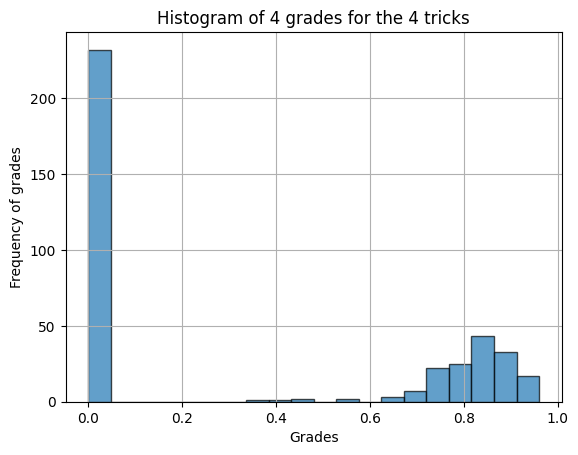

In [19]:

#Convert the 4D dimensional array into a 1D array and use matplotlib to plot the hisotogram.
grades = df[['trick 1', 'trick 2', 'trick 3', 'trick 4']].values.flatten()

# Plot histogram
plt.hist(grades, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Grades')
plt.ylabel('Frequency of grades')
plt.title('Histogram of 4 grades for the 4 tricks')
plt.grid(True)
plt.show()



#It appears that most of the tricks attempted resulted in zero points which means the contenders failed.



(c)For each trick 1−4 create a new column named 'make i' for i = 1, 2, 3, 4 such that the value of 'make i' in a given row is 1 if the skateboarder landed trick i and 0 otherwise

In [20]:
"""I looped through each contender and checked if they had a nonzero entry,
if that was the case i populated the make column with 0 and 1 otherwise """


make_columns = ["make 1", "make 2", "make 3", "make 4"]
for make_column in make_columns:
    df[make_column] = np.nan

for i, make_column in enumerate(make_columns, start=1):
    trick_column = f'trick {i}'
    df[make_column] = df[trick_column].apply(lambda x: 1 if x > 0 else 0)


df #View data

,id,location,month,year,comp,heat,run 1,run 2,trick 1,trick 2,trick 3,trick 4,trick 5,trick 6,make 1,make 2,make 3,make 4
0,Berger,jacksonville,7,2022,prelim men,1,0.50,0.11,0.70,0.00,0.76,0.00,NaN,NaN,1,0,1,0
1,Papa,jacksonville,7,2022,prelim men,1,0.37,0.70,0.72,0.00,0.84,0.82,NaN,NaN,1,0,1,1
2,Pudwill,jacksonville,7,2022,prelim men,1,0.20,0.13,0.00,0.00,0.00,0.00,NaN,NaN,0,0,0,0
3,Shirai,jacksonville,7,2022,prelim men,1,0.79,0.70,0.75,0.00,0.92,0.00,NaN,NaN,1,0,1,0
4,Mota,jacksonville,7,2022,prelim men,1,0.38,0.40,0.78,0.00,0.00,0.00,NaN,NaN,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,Hoban,las vegas,10,2022,final men,1,0.62,0.88,0.86,0.00,0.88,0.00,0.00,0.00,1,0,1,0
93,Hoefler,las vegas,10,2022,final men,1,0.84,0.57,0.78,0.00,0.87,0.00,0.00,0.00,1,0,1,0
94,Eaton,las vegas,10,2022,final men,1,0.69,0.72,0.00,0.84,0.75,0.00,NaN,NaN,0,1,1,0
95,Joslin,las vegas,10,2022,final men,1,0.68,0.83,0.79,0.83,0.00,0.00,0.89,0.94,1,1,0,0


(d) För varje skateboardåkare skatta sannolikheten att ett trick får ett betyg
som är större än 0.6 givet att skateboardåkaren landar tricket. Vad är sannolikheten att skateboardåkaren inte lyckas landa ett visst trick? Vad observerar
du? Relatera dina observationer till era observationer i del (b).


"According to Bayes' theorem, we have $P(A \mid B)=\frac{P(B \mid A) P(A)}{P(B)}$.
If we let $L=$ Successful trick
and $S$ as a score greater than 0.6 .
we get $P(S \mid L)=\frac{P(L \mid S) P(S)}{P(L)}$.
But $P(L \mid S) P(S)=1 \times P(S)$, so we get the expression
$$
P(S \mid L)=\frac{P(S)}{P(L)} "
$$

Probability for contender Berger to land a trick with a score higher than 0.6 is 0.50
Probability for contender Papa to land a trick with a score higher than 0.6 is 0.75
Probability for contender Pudwill to land a trick with a score higher than 0.6 is 0.00
Probability for contender Shirai to land a trick with a score higher than 0.6 is 0.50
Probability for contender Mota to land a trick with a score higher than 0.6 is 0.25
Probability for contender Ribeiro G to land a trick with a score higher than 0.6 is 0.50
Probability for contender Decenzo to land a trick with a score higher than 0.6 is 0.25
Probability for contender Hoefler to land a trick with a score higher than 0.6 is 0.25
Probability for contender Foy to land a trick with a score higher than 0.6 is 0.75
Probability for contender Hoban to land a trick with a score higher than 0.6 is 0.00
Probability for contender Midler to land a trick with a score higher than 0.6 is 0.25
Probability for contender Milou to land a trick with a s

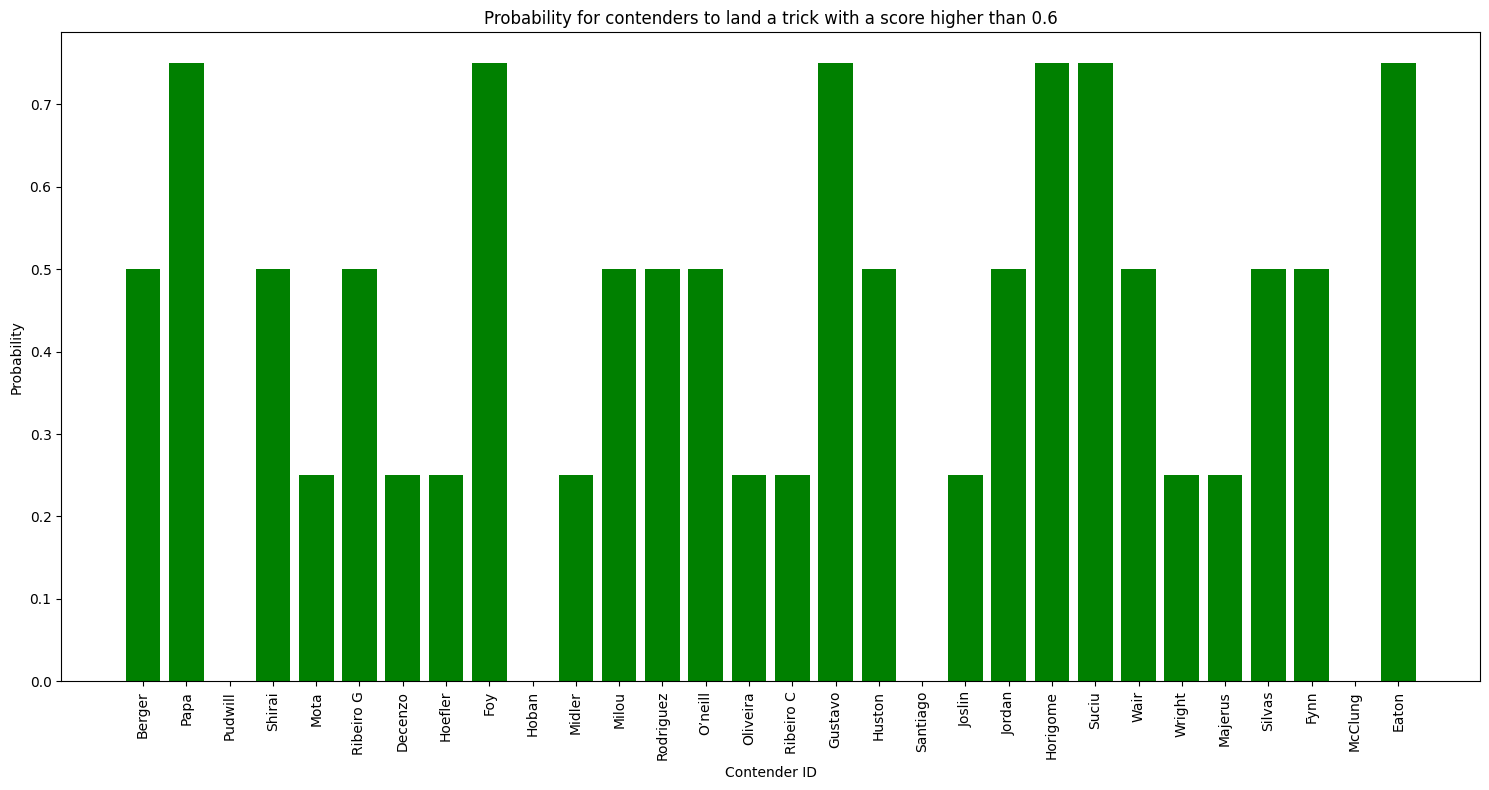

In [21]:

contestants = df["id"]

# Collect data
contender_names = []
probabilities = []

for contender in contestants:
    rowval = df.loc[df['id'] == str(contender), ['trick 1', 'trick 2', 'trick 3', 'trick 4']].values[0]
    attempts = [val for val in rowval if not pd.isna(val)]
    success = len([x for x in attempts if x > 0.6])
    if len(attempts) != 0:  #  zero division
        prob = success / len(attempts)
        print(f"Probability for contender {contender} to land a trick with a score higher than 0.6 is {prob:.2f}")

        contender_names.append(contender)
        probabilities.append(prob)
    else:
        print(f"Contender {contender} has no valid attempts.")

# plotting
plt.figure(figsize=(15, 8))
plt.bar(contender_names, probabilities, color='green')
plt.xlabel('Contender ID')
plt.ylabel('Probability')
plt.title('Probability for contenders to land a trick with a score higher than 0.6')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


**Gör ett spridningsdiagram för runbetyg 1 mot runbetyg 2. Ser du någon tydligt korrelation från diagrammet?**

A consistent correlation cant be seen across the graph but around around the scores 0.6 -0.8 we see some clustering of the scores.

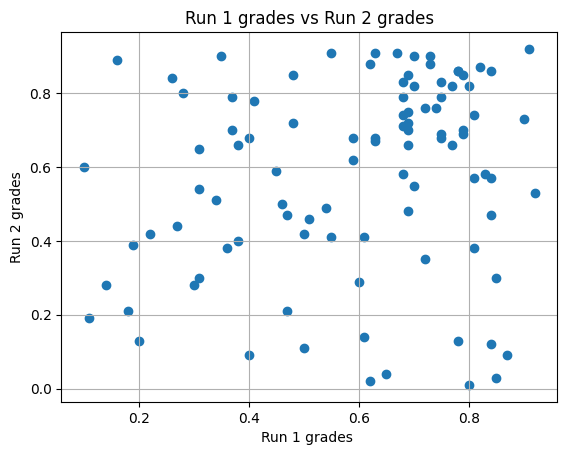

In [22]:
plt.scatter(df['run 1'], df['run 2'])
plt.title('Run 1 grades vs Run 2 grades')
plt.xlabel('Run 1 grades ')
plt.ylabel('Run 2 grades')
plt.grid(True)
plt.show()




Based on the observations from Task 1, an appropriate model for \(X_i\) is:
\begin{equation}
X_i=
\begin{cases}
0 & \text{if } V_i=0 \\
Z_i & \text{if } V_i=1
\end{cases}
\end{equation}
where $V_i \sim \operatorname{Ber}\left(\theta_i\right), Z_i \sim \operatorname{Beta}\left(\alpha_i, \beta_i\right)$ and $V_i \perp Z_i$. It can be shown that
$$
f_{X_i}\left(x_i \mid \theta_i, \alpha_i, \beta_i\right)=\left(1-\theta_i\right) \mathbf{1}_{x_i=0}+\theta_i f_{Z_i}\left(z_i\right) .
$$
The choice $V_i \sim \operatorname{Ber}\left(\theta_i\right)$ models that a skateboarder receives a score of 0 if and only if they do not successfully land the trick, while the choice $Z_i \sim \operatorname{Beta}\left(\alpha_i, \beta_i\right)$ models that the score for a particular trick is the portion of the trick that was "perfect."


**bold text**

**Ge en punktskattning för varje $\theta_i$, sannolikheten att skateboardåkaren $i$ landar ett trick.**



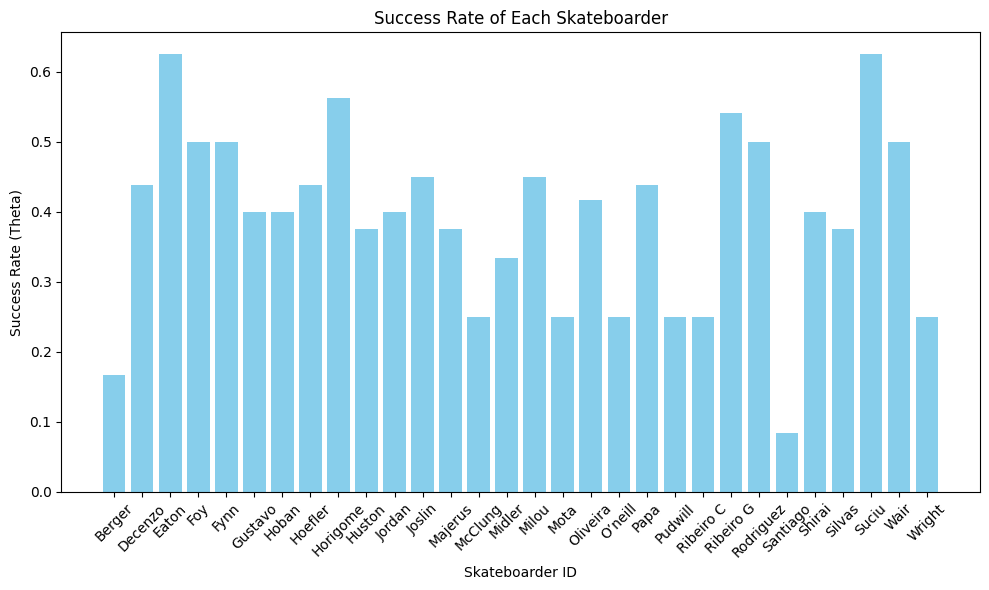

In [23]:

success_rates = df.groupby('id')[['make 1', 'make 2', 'make 3', 'make 4']].mean().mean(axis=1)
thetas = success_rates.to_dict()

# Plotting
plt.figure(figsize=(10, 6))
names = list(thetas.keys())
values = list(thetas.values())

plt.bar(names, values, color='skyblue')
plt.xlabel('Skateboarder ID')
plt.ylabel('Success Rate (Theta)')
plt.title('Success Rate of Each Skateboarder')
plt.xticks(rotation=45)  # Rotate names
plt.tight_layout()

plt.show()





The likelihood function is:
\begin{equation}
L(\alpha, \beta \mid \mathbf{Z})=\prod_{i=1}^n \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha) \Gamma(\beta)} z_i^{\alpha-1}\left(1-z_i\right)^{\beta-1}=\left(\frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha) \Gamma(\beta)}\right)^n \prod_{i=1}^n\left(z_i\right)^{\alpha-1} \prod_{i=1}^n\left(1-z_i\right)^{\beta-1}
\end{equation}

Taking the log of the likelihood function we get,
\begin{align}
\log L(\alpha, \beta \mid \mathbf{Z}) & =n \log (\Gamma(\alpha+\beta))-n \log (\Gamma(\alpha))-n \log (\Gamma(\beta)) \\
& +(\alpha-1) \sum_{i=1}^n \log \left(z_i\right)+(\beta-1) \sum_{i=1}^n \log \left(1-z_i\right)
\end{align}

To find the point estimates for \$(\left[\alpha, \beta_i\right]^{\mathrm{T}}$\), we need to take the partial derivatives with respect to (\alpha\) and \(\beta\) and set them to zero. The stationary points for each derivative are:
\begin{align}
\frac{\partial}{\partial \alpha} \log L(\alpha, \beta \mid \mathbf{Z}) & = n \psi(\alpha+\beta) - n \psi(\alpha) + \sum_{i=1}^n \log \left(z_i\right) = 0 \\
\frac{\partial}{\partial \beta} \log L(\alpha, \beta \mid \mathbf{Z}) & = n \psi(\alpha+\beta) - n \psi(\beta) + \sum_{i=1}^n \log \left(1-z_i\right) = 0
\end{align}

Where $(\psi(x))$ is the digamma function, which is the logarithmic derivative of the gamma function: $(\psi(x) = \frac{d}{dx} \log \Gamma(x)$\).

Note: \$(z_i: z \neq 0,1$\).


The initial guess for the $\theta=[α̂,β̂]$ will be the moment of estimators, which are:

\begin{equation}
\hat{\alpha}_{M O M}=\bar{Z}\left(\frac{\bar{Z}(1-\bar{Z})}{S^2}-1\right) \quad \text { and } \quad \hat{\beta}_{M O M}=(1-\bar{Z})\left(\frac{\bar{Z}(1-\bar{Z})}{S^2}-1\right)
\end{equation}



In [24]:
from scipy.special import psi, polygamma

def digamma(x): #digamma function
    return psi(x)

def trigamma(x):
    return polygamma(1, x)

def method_of_moments(scores):
    mean_xi = np.mean(scores)
    # Using sample variance by setting ddof to 1
    var_xi = np.var(scores, ddof=1)
    a = mean_xi * (mean_xi * (1 - mean_xi) / var_xi - 1)
    b = (1 - mean_xi) * (mean_xi * (1 - mean_xi) / var_xi - 1)
    return a, b



Newton raphsons method has the form:

\begin{equation}
\boldsymbol{\theta}_{n+1}=\boldsymbol{\theta}_n-J\left(\boldsymbol{\theta}_n\right)^{-1} \boldsymbol{F}\left(\boldsymbol{\theta}_n\right)
\end{equation}


We need to iterate through each contender listed in the "id" column and examine their scores in the columns for tricks 1-4, excluding scores that are 0 . The aggregated scores for each contender are then used to obtain an initial guess, $\left[\alpha_0, \beta_0\right]$, for the Newton-Raphson method by leveraging the method of moments. However, some contenders have only one non-zero entry across the columns for tricks $1-4$. This leads to a division by zero error in the calculation for $\hat{\beta}$ since we're dividing by the sample variance, which becomes 0 . To address this, we identify contenders with fewer than 2 non-zero entries in the tricks columns and rely on the method of moments across all their scores in columns trick 1-4 to estimate both $\hat{\alpha}$ and $\hat{\beta}$ for these contenders.

An error tolerance of $10^{-6}$ and an iteration limit of 1000 is provided in the Newton-Raphson method to ensure convergence.


In [25]:
def newton_raphson(x, tol=1e-6, max_iter=1000):
    # ta bort 0
    x = x[x != 0]
    mean_x = np.mean(x)
    #degrees of freedom är 1 dfe
    var_x = np.var(x, ddof=1)
    alpha0 = mean_x * (mean_x * (1 - mean_x) / var_x - 1)
    beta0 = (1 - mean_x) * (mean_x * (1 - mean_x) / var_x - 1)
    theta = np.array([alpha0, beta0])
    for _ in range(max_iter):
        g1 = digamma(theta[0]) - digamma(np.sum(theta)) - np.mean(np.log(x))
        g2 = digamma(theta[1]) - digamma(np.sum(theta)) - np.mean(np.log(1-x))
        g = np.array([g1, g2])
        G = np.array([
            [trigamma(theta[0]) - trigamma(np.sum(theta)), -trigamma(np.sum(theta))],
            [-trigamma(np.sum(theta)), trigamma(theta[1]) - trigamma(np.sum(theta))]
        ])
        theta = theta - np.linalg.inv(G) @ g
        if np.linalg.norm(g) < tol:
            return theta
    raise ValueError(f"Newton-Raphson did not converge after {max_iter} iterations")

columns_to_filter = ['trick 1', 'trick 2', 'trick 3', 'trick 4', 'trick 5', 'trick 6']

grouped_data = df.groupby('id')[columns_to_filter].apply(lambda x: [item for sublist in x.values for item in sublist if not np.isnan(item)]).to_dict()

alphas_tricks = {}  # a dict alpha
betas_tricks = {}   # a dict beta

for skateboarder, scores in grouped_data.items():
    #convert to array
    scores = np.array(scores)

    # moments if u have 0 scores
    if 1 in scores or len(scores[scores != 0]) == 1:
        a, b = method_of_moments(scores)
    else:
        try:
            a, b = newton_raphson(scores)
        except Exception as e:
            # if Newton-Raphson fails use method of moments
            a, b = method_of_moments(scores)

    #  alphas and betas for each skateboarder in the dictionariess
    alphas_tricks[skateboarder] = a
    betas_tricks[skateboarder] = b




Plotting the results

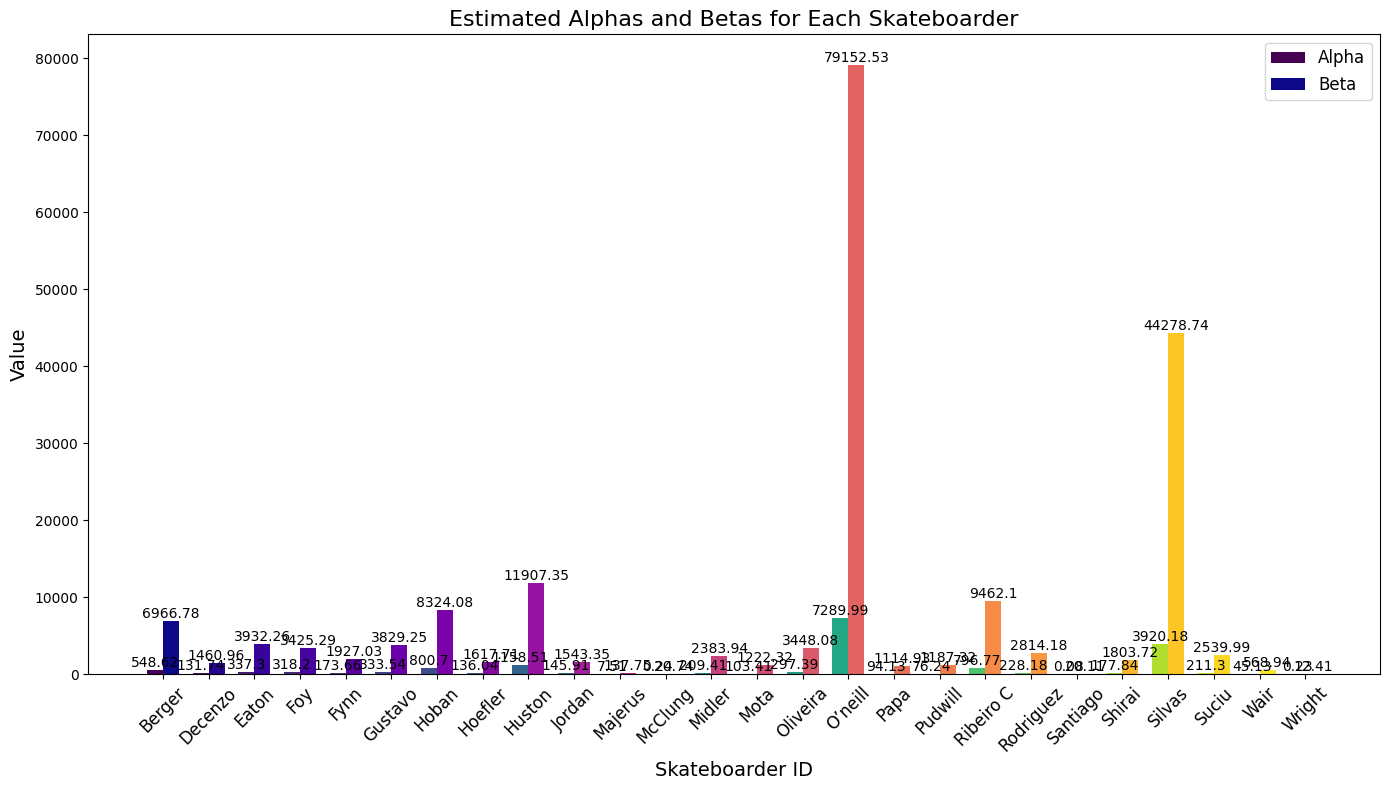

In [ ]:
df_results = pd.DataFrame({
    'Alpha': alphas_tricks,
    'Beta': betas_tricks
})

# Plotting
fig, ax = plt.subplots(figsize=(14, 8))
N = len(df_results)
ind = np.arange(N)
width = 0.35

p1 = ax.bar(ind, df_results['Alpha'], width, label='Alpha', color=plt.cm.viridis(np.linspace(0, 1, N)))
p2 = ax.bar(ind + width, df_results['Beta'], width, label='Beta', color=plt.cm.plasma(np.linspace(0, 1, N)))

for i in range(N):
    ax.text(i, df_results['Alpha'].iloc[i] + 0.01, round(df_results['Alpha'].iloc[i], 2), ha='center', va='bottom', fontsize=10)
    ax.text(i + width, df_results['Beta'].iloc[i] + 0.01, round(df_results['Beta'].iloc[i], 2), ha='center', va='bottom', fontsize=10)

ax.set_title('Estimated Alphas and Betas for Each Skateboarder', fontsize=16)
ax.set_ylabel('Value', fontsize=14)
ax.set_xlabel('Skateboarder ID', fontsize=14)
ax.set_xticks(ind + width / 2)
ax.set_xticklabels(df_results.index, rotation=45, fontsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('grouped_alphas_betas_plot.png')
plt.show()


**Föreslå en modell för $Y_i$ och ge en punktskattning för dina modells parametrar. Motivera dina val för modell och punktskattning.**

Let $Y_i$ denote the score for the $i^{t h}$ run. Given that each run's score $Y_i$ lies in the support interval $[0,1]$, it is reasonable to model the variability in scores using a probability distribution that is defined on this interval. Considering the heterogeneity in performance across contenders, a suitable choice for modeling the distribution of scores is the Beta distribution.

The probability density function (pdf) of the Beta distribution is given by:
$$
f(y ; \alpha, \beta)=\frac{y^{\alpha-1}(1-y)^{\beta-1}}{B(\alpha, \beta)}
$$

We can implement Newton Raphsons method with initial starting points for $α_0$ and $β_0$ obtained from moments of estimators.

In [26]:

columns_to_filter = ['run 1', 'run 2']

grouped_data = df.groupby('id').apply(lambda x: np.concatenate([x['run 1'].values, x['run 2'].values])).to_dict()

alphas_runs = {}  # Initializing empty dictionary
betas_runs = {}

for skateboarder, scores in grouped_data.items():
    scores = np.array(scores)

    try:
        a, b = newton_raphson(scores)
    except Exception as e:
        a, b = method_of_moments(scores)

    alphas_runs[skateboarder] = a
    betas_runs[skateboarder] = b

print("Alphas for runs:", alphas_runs)
print("Betas for runs:", betas_runs)

skateboarders = list(alphas_runs.keys())
alpha_values = list(alphas_runs.values())
beta_values = list(betas_runs.values())
df_parameters = pd.DataFrame({
    'Skateboarder': skateboarders,
    'Alpha': alpha_values,
    'Beta': beta_values
})

# Display the table
print(df_parameters)


Alphas for runs: {'Berger': 2.6755889441520124, 'Decenzo': 4.297796895197104, 'Eaton': 102.37780702788777, 'Foy': 2.835827679897586, 'Fynn': 5.6043746070740355, 'Gustavo': 1.5655522715776213, 'Hoban': 3.839819264550563, 'Hoefler': 1.414922374606775, 'Horigome': 15.069232009992223, 'Huston': 7.61198496910501, 'Jordan': 4.7111386446297745, 'Joslin': 11.930458298230416, 'Majerus': 1.6812584550479617, 'McClung': 2585.9823814278684, 'Midler': 0.8446197032047025, 'Milou': 6.644678612844529, 'Mota': 4.110896945319107, 'Oliveira': 5.299017829168913, 'O’neill': 0.9093678769679341, 'Papa': 2.3593234650951533, 'Pudwill': 4.905220004860534, 'Ribeiro C': 2.067175542567843, 'Ribeiro G': 6.2525663954809225, 'Rodriguez': 3.4748510560521764, 'Santiago': 2.76334253010078, 'Shirai': 1.5694339864779077, 'Silvas': 0.8217101442969286, 'Suciu': 3.365321315783447, 'Wair': 3.1443492282085055, 'Wright': 597.0270300984907}
Betas for runs: {'Berger': 4.484918674619557, 'Decenzo': 2.8985428000550906, 'Eaton': 36.4

In [27]:
success_rates = df.groupby('id')[['make 1', 'make 2', 'make 3', 'make 4']].mean().mean(axis=1)

thetas = success_rates.to_dict()

print(f"Probability of each contender to land a trick is:")
for skateboarder, theta in thetas.items():
    print(f"Skateboarder: {skateboarder}, Success Rate (Theta): {theta}")


Probability of each contender to land a trick is:
Skateboarder: Berger, Success Rate (Theta): 0.16666666666666666
Skateboarder: Decenzo, Success Rate (Theta): 0.4375
Skateboarder: Eaton, Success Rate (Theta): 0.625
Skateboarder: Foy, Success Rate (Theta): 0.5
Skateboarder: Fynn, Success Rate (Theta): 0.49999999999999994
Skateboarder: Gustavo, Success Rate (Theta): 0.4
Skateboarder: Hoban, Success Rate (Theta): 0.39999999999999997
Skateboarder: Hoefler, Success Rate (Theta): 0.4375
Skateboarder: Horigome, Success Rate (Theta): 0.5625
Skateboarder: Huston, Success Rate (Theta): 0.375
Skateboarder: Jordan, Success Rate (Theta): 0.4
Skateboarder: Joslin, Success Rate (Theta): 0.44999999999999996
Skateboarder: Majerus, Success Rate (Theta): 0.375
Skateboarder: McClung, Success Rate (Theta): 0.25
Skateboarder: Midler, Success Rate (Theta): 0.3333333333333333
Skateboarder: Milou, Success Rate (Theta): 0.44999999999999996
Skateboarder: Mota, Success Rate (Theta): 0.25
Skateboarder: Oliveira, S

In [28]:
import pandas as pd

params_df = pd.DataFrame(columns=['Skateboarder', 'Theta', 'Alpha_Trick', 'Beta_Trick'])

for skateboarder in df['id'].unique():
    params_df = params_df.append({
        'Skateboarder': skateboarder,
        'Theta': thetas[skateboarder],
        'Alpha_Trick': alphas_tricks[skateboarder],
        'Beta_Trick': betas_tricks[skateboarder]
    }, ignore_index=True)

# Skriv ut DataFrame
#print(params_df)


<ipython-input-28-7339bf97b6a3>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  params_df = params_df.append({
<ipython-input-28-7339bf97b6a3>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  params_df = params_df.append({
<ipython-input-28-7339bf97b6a3>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  params_df = params_df.append({
<ipython-input-28-7339bf97b6a3>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  params_df = params_df.append({
<ipython-input-28-7339bf97b6a3>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  params_df = params_df.appe

**bold (d) Använd din modell för $\left[X_i, Y_i\right]^{\mathrm{T}}$ för att simulera 5000 LCQ:ar och för varje simulering extrahera de fyra skateboardåkare $\boldsymbol{W}=\left[W_1, W_2, W_3, W_4\right]^{\mathrm{T}}$ med de högsta totalbetygen. Vad är typvärdet för $\boldsymbol{W}_1, \ldots, \boldsymbol{W}_{5000}$ ? De riktiga vinnarna för LCQ:en är
Gustavo Hoban Eaton Decenzo.
Hur många av de riktiga vinnarna förutsägs av typvärdet? Vad är skattade sannolikheten för de riktiga vinnarna baserat på dina simuleringar? Av typvärdet?  text**

We need to remove the already qualified contenders namely Horigome Joslin Milou Ribeiro G. Then simulate the LCQ for each contender. After running the simulation the most common winners were Huston,Jordan,Shirai and Hoban. The estimated probability of the actual winners based on the simulations: 0.4%.

In [29]:
from collections import Counter

N_SIMULATIONS = 5000
# remove the already qualified skateboarders
df = df[~df['id'].isin(['Horigome', 'Joslin', 'Milou', 'Ribeiro G'])]

winners = []

for _ in range(N_SIMULATIONS):
    total_scores = {}
    for skateboarder in df['id'].unique():
        trick_scores = [np.random.beta(alphas_tricks[skateboarder], betas_tricks[skateboarder]) if np.random.binomial(1, thetas[skateboarder]) else 0 for _ in range(4)]
        top_trick_scores = sum(sorted(trick_scores)[-2:])
        run_scores = [np.random.beta(alphas_runs[skateboarder], betas_runs[skateboarder]) for _ in range(2)]
        top_run_score = max(run_scores)

        # totall score
        total_scores[skateboarder] = top_trick_scores + top_run_score
    sorted_scores = sorted(total_scores.items(), key=lambda x: x[1], reverse=True)
    winners += [skater[0] for skater in sorted_scores[:4]]

# count the occurrences
counter = Counter(winners)
print(counter)



Counter({'Huston': 2291, 'Jordan': 2209, 'Shirai': 1981, 'Hoban': 1938, 'Eaton': 1399, 'Suciu': 1382, 'Decenzo': 1253, 'Hoefler': 1073, 'Gustavo': 1060, 'Midler': 919, 'Foy': 757, 'Wair': 619, 'Silvas': 611, 'Papa': 562, 'Fynn': 510, 'O’neill': 502, 'Oliveira': 476, 'Ribeiro C': 201, 'Rodriguez': 135, 'Mota': 103, 'Majerus': 12, 'Wright': 5, 'Berger': 2})


Next we can visualize the winners and the estimated probability of the actual winners based on the simulations.

The most common winners are: [('Huston', 2291), ('Jordan', 2209), ('Shirai', 1981), ('Hoban', 1938)]
Number of actual winners predicted by the mode: 1
Estimated probability of the actual winners based on the simulations: 0.0002


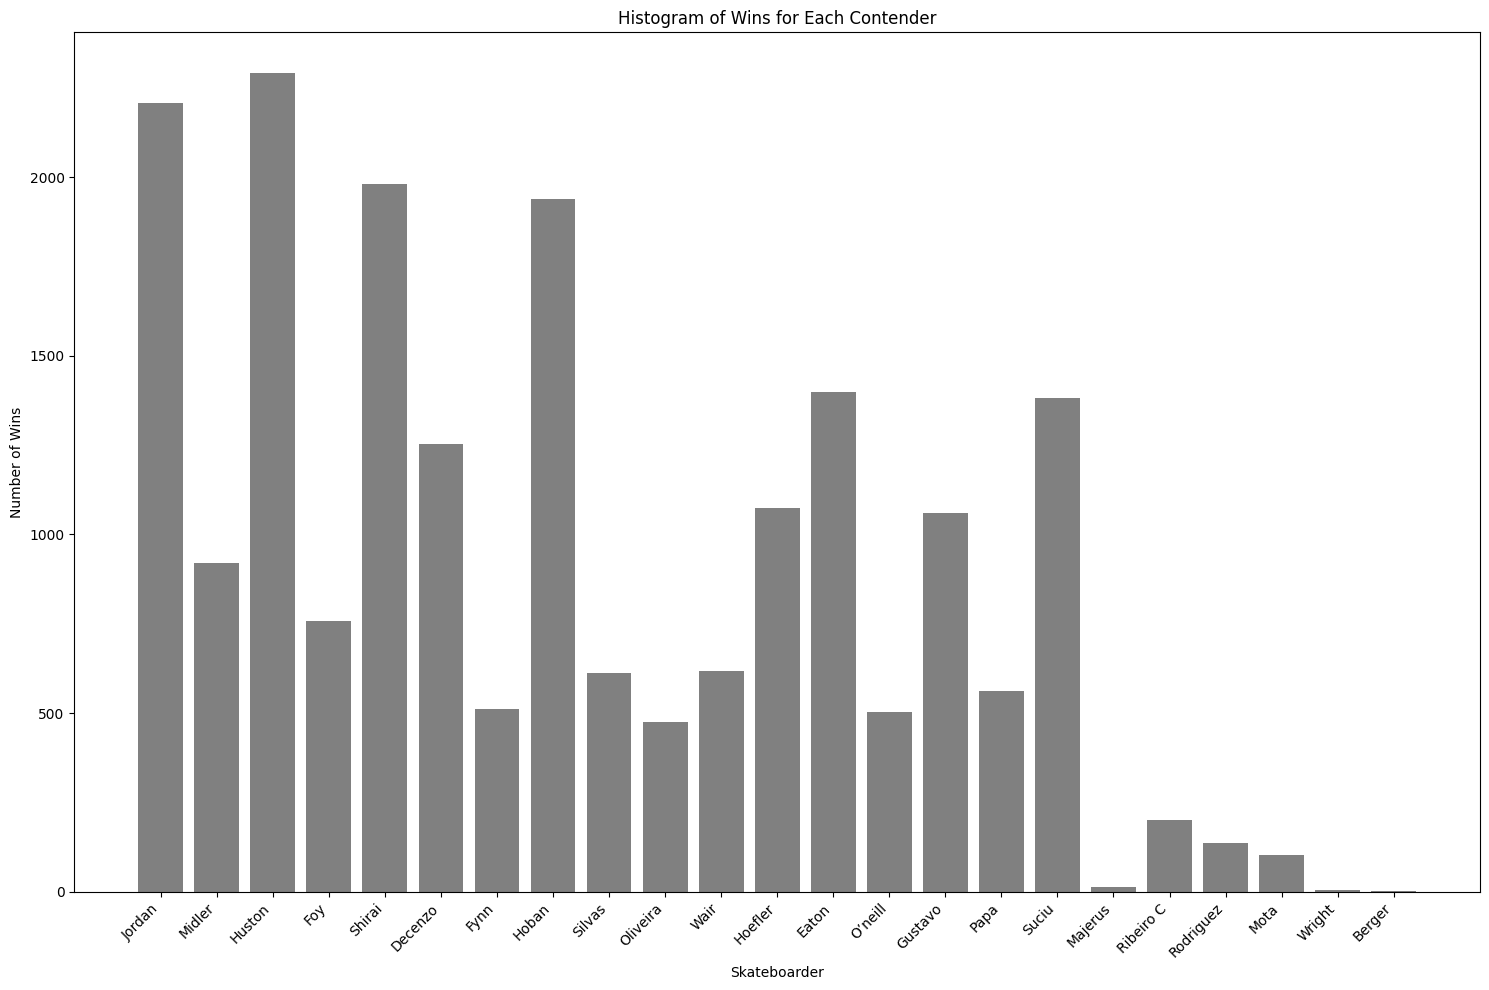

In [30]:
most_common_winners = counter.most_common(4)
print(f"The most common winners are: {most_common_winners}")
actual_winners = ["Gustavo", "Hoban", "Eaton", "Decenzo"]
predicted_winners = [winner[0] for winner in most_common_winners]
correct_predictions = len(set(predicted_winners).intersection(set(actual_winners)))
print(f"Number of actual winners predicted by the mode: {correct_predictions}")

# probability of the actual winners
probability_actual_winners = sum([1 for i in range(0, len(winners), 4) if set(winners[i:i+4]) == set(actual_winners)]) / N_SIMULATIONS
print(f"Estimated probability of the actual winners based on the simulations: {probability_actual_winners}")
skateboarders = list(counter.keys())
counts = list(counter.values())

# histogram
plt.figure(figsize=(15, 10))
plt.bar(skateboarders, counts, color='grey')
plt.xlabel('Skateboarder')
plt.ylabel('Number of Wins')
plt.title('Histogram of Wins for Each Contender')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In this section we would like to approximate the posterior distrubition $f(\alpha,\beta,\theta)$, we can use the metropolis algorithm with a a normal distributed step function. We begin by accesing all the scores and parameters and store them in arrays and lists.

In [37]:

from scipy.special import loggamma

contender_ids = df['id'].unique()

c_scores_list = []

for contender_id in contender_ids:
    contender_data = df[df['id'] == contender_id]

    tricks = contender_data[['trick 1', 'trick 2', 'trick 3', 'trick 4']].values.flatten()

    valid_tricks = [score for score in tricks if 0 <= score <= 1]

    c_scores_list.append(valid_tricks)

c_scores = np.array(c_scores_list, dtype=object)
data = [score for sublist in c_scores for score in sublist]

theta_point = [
    params_df[params_df['Skateboarder'] == contender_id]['Theta'].values[0]
    for contender_id in contender_ids
]

alpha_point = [
    params_df[params_df['Skateboarder'] == contender_id]['Alpha_Trick'].values[0]
    for contender_id in contender_ids
]

beta_point = [
    params_df[params_df['Skateboarder'] == contender_id]['Beta_Trick'].values[0]
    for contender_id in contender_ids
]


contender_ids = df['id'].unique()

# Dictionary to store scores for each contender
contender_scores = {}

for contender_id in contender_ids:
    contender_data = df[df['id'] == contender_id]

    tricks = contender_data[['trick 1', 'trick 2', 'trick 3', 'trick 4']].values.flatten()

    valid_tricks = [score for score in tricks if 0 <= score <= 1]

    if contender_id in contender_scores:
        contender_scores[contender_id].extend(valid_tricks)
    else:
        contender_scores[contender_id] = valid_tricks





**(a) Föreslå en simultan apriorifördelning för parametrarna $\left[\Theta_i, A_i, B_i\right]^{\mathrm{T}}$ för $X_i$ där vi antar $\Theta_i$ är oberoende av $A_i, B_i$ för alla $i$. Motivera ditt val.**

 Since $\theta$ is independent of $A$ and $B$, the simultaneous prior can be expressed as $f_\theta(\theta) \times f_{\alpha, \beta}(\alpha, \beta)$. Starting with a prior for $\theta$, we can assume a non-informative prior, so we get $f(\theta \propto 1$. If we build the hierarcal model,

$\begin{aligned} \kappa \mid \mu & \sim \operatorname{Gamma}(\theta, \lambda), \\ \mu & \sim \mathrm{U}(0,1) .\end{aligned}$

Where $\mu=\frac{\alpha}{\alpha+\beta}$ and $\kappa=\alpha+\beta+1$. After a transformation we get the joint priori as:

 $f_{A, B}(\alpha, \beta)=\frac{\lambda^\theta}{\Gamma(\theta)}(\alpha+\beta+1)^{\theta-1} e^{-\lambda(\alpha+\beta+1)}(\alpha+\beta)^{-1}$.
 The joint posterior distribution then becomes,
 $\begin{aligned} & f_{\Theta_i, A_i, B_i \mid \boldsymbol{X}_i}\left(\theta_i, \alpha_i, \beta_i \mid \boldsymbol{x}_i\right) \propto \\ & 1 * \prod_{i=1}^n\left(\left(1-\theta_i\right) \mathbf{1}_{x_i=0}+\theta_i \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)+\Gamma(\beta)} z_i^{\alpha-1}(1-z)^{\beta-1} \mathbf{1}_{x_i \neq 0}\right) \times \\ & \frac{\lambda^\theta}{\Gamma(\theta)}(\alpha+\beta+1)^{\theta-1} e^{-\lambda(\alpha+\beta+1)}(\alpha+\beta)^{-1}\end{aligned}$

 Choosing $κ=ᾱ+β̄+1$ and $λ=4$

 Because the likelihood function can get big for certain values and because it's easier to deal with logarithms we take the log of the expression and later exponantiate it when we plot the counterplots.
 So we have, \[
\begin{aligned}
\log & f_{\Theta_i, A_i, B_i \mid \boldsymbol{X}_i}\left(\theta_i, \alpha_i, \beta_i \mid \boldsymbol{x}_i\right) = \\
& \log(1) + \sum_{i=1}^n \left( \log\left(\left(1-\theta_i\right) \mathbf{1}_{x_i=0}\right) + \log\left(\theta_i \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)+\Gamma(\beta)} z_i^{\alpha-1}(1-z)^{\beta-1} \mathbf{1}_{x_i \neq 0}\right) \right) + \\
& \log\left(\frac{\lambda^\theta}{\Gamma(\theta)}\right) + (\theta-1) \log(\alpha+\beta+1) - \lambda(\alpha+\beta+1) - \log(\alpha+\beta)
\end{aligned}
\]





In [50]:
from scipy.special import gammaln

def likelihood(theta, alpha, beta, data):
    LH = 0
    for x in data:
        if x == 0:
            LH += np.log(1 - theta)
        else:
            log_term = np.log(theta) + (gammaln(alpha + beta) - gammaln(alpha) - gammaln(beta)) + (alpha - 1) * np.log(x) + (beta - 1) * np.log(1 - x)
            LH += log_term
    return LH



def priori(alpha, beta, k, λ):
    λ=float(λ)
    k=float(k)
    θ = λ * k
    return np.log(θ**λ)-loggamma(θ)+(θ-1)*np.log(alpha+beta+1)-λ*(alpha+beta+1)-np.log(alpha+beta)




We let θ=0.5 and calculate the joint posterior.

In [51]:
ma=np.mean(alpha_point)
mb=np.mean(beta_point)
stda=np.std(alpha_point)
stdb=np.std(beta_point)
def log_posterior(alpha, beta,data):
    priorii = priori(alpha, beta, ma+mb+1, 6)
    likelihoood = likelihood(0.5,alpha,beta,data)
    return priorii + likelihoood




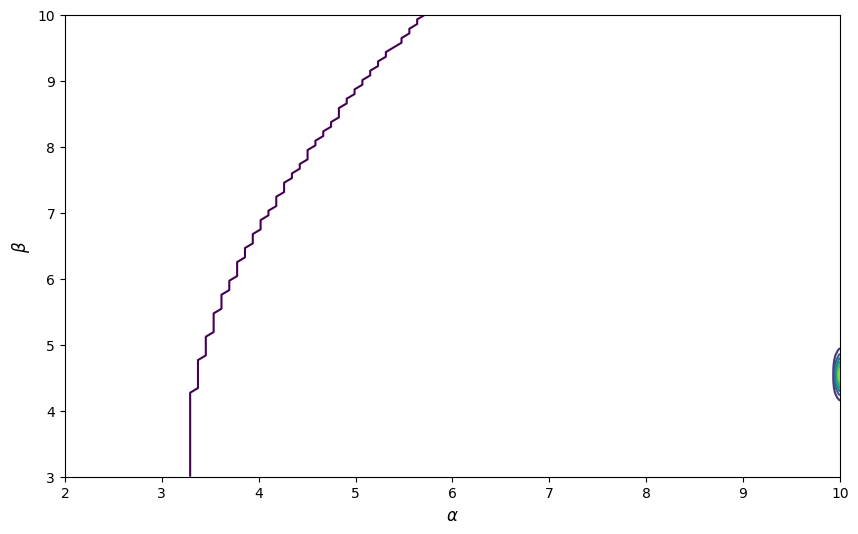

In [52]:
ma=np.mean(alpha_point)
mb=np.mean(beta_point)
stda=np.std(alpha_point)
stdb=np.std(beta_point)

alpha_grid = np.linspace(2, 10, 100)
beta_grid = np.linspace(3, 10, 100)

log_posterior_grid = [[log_posterior(alpha,beta,data) for alpha in alpha_grid] for beta in beta_grid]

posterior_grid = np.exp(log_posterior_grid - np.max(log_posterior_grid))

plt.figure(figsize=(10, 6))
plt.contour(alpha_grid, beta_grid, posterior_grid)
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"$\beta$", fontsize=12)

plt.show()

METROPOLIS ALGORITHM